# Customer Segmentation & Marketing Campaign Analytics
## Phase 2 — SQL Exploration

**Goal of this notebook.** Ask `bank_clean` five business questions in SQL, and read off which
kinds of customers respond to this campaign, and when and how they were reached. This is
descriptive, group-by-and-compare SQL, the everyday kind an analytics team runs before building
anything more elaborate, and it is what Phase 3's segments will need to line up with.

**Input.** `bank_clean`, built by notebook 1 (`bank_marketing.duckdb`). Run notebook 1 first if
that file doesn't exist yet.

**Two numbers on every table below.** Each query reports not just the subscription rate but also
what share of all customers fall into that group. A high rate on a group that is 2% of customers
is a different finding from the same rate on a group that is 30% of customers, and Phase 4 will
need exactly this pairing to say which segments are worth prioritizing.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import connect, run_sql_file

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

con = connect()
n_clean = con.execute("SELECT COUNT(*) FROM bank_clean").fetchone()[0]
overall_rate = con.execute("SELECT AVG(CASE WHEN subscribed THEN 1.0 ELSE 0 END) FROM bank_clean").fetchone()[0]
print(f"bank_clean: {n_clean:,} customers, overall subscribe rate {overall_rate:.1%}")

bank_clean: 45,211 customers, overall subscribe rate 11.7%


## 1. Subscription rate by job

`sql/08_subscription_rate_by_job.sql`

In [2]:
job = run_sql_file(con, "08_subscription_rate_by_job.sql")
job

,job,n_customers,pct_of_all_customers,subscribe_rate_pct
0,student,938,2.07,28.68
1,retired,2264,5.01,22.79
2,unemployed,1303,2.88,15.50
3,management,9458,20.92,13.76
4,admin.,5171,11.44,12.20
5,self-employed,1579,3.49,11.84
6,unknown,288,0.64,11.81
7,technician,7597,16.80,11.06
8,services,4154,9.19,8.88
9,housemaid,1240,2.74,8.79


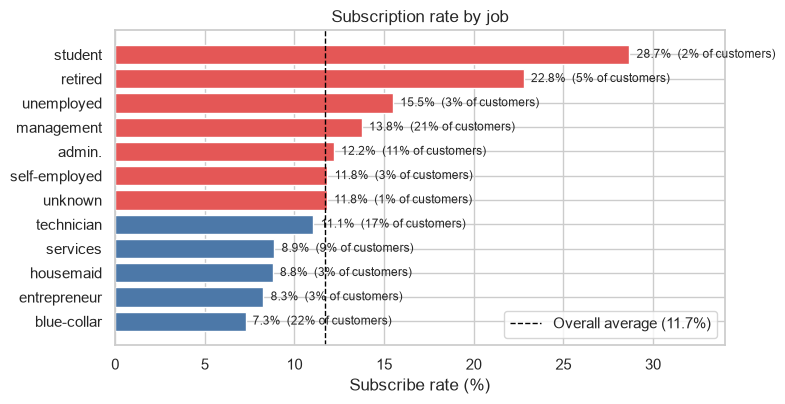

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#E45756" if r >= overall_rate*100 else "#4C78A8" for r in job.subscribe_rate_pct]
ax.barh(job.job[::-1], job.subscribe_rate_pct[::-1], color=colors[::-1])
ax.axvline(overall_rate*100, color="black", ls="--", lw=1, label=f"Overall average ({overall_rate:.1%})")
for i, (r, n) in enumerate(zip(job.subscribe_rate_pct[::-1], job.pct_of_all_customers[::-1])):
    ax.text(r + 0.4, i, f"{r:.1f}%  ({n:.0f}% of customers)", va="center", fontsize=8.5)
ax.set_xlabel("Subscribe rate (%)"); ax.set_title("Subscription rate by job")
ax.set_xlim(0, 34); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/02_subscribe_by_job.png", dpi=150)
plt.show()

**What this shows.** **Students (28.7%) and retirees (22.8%) respond far above the 11.7% average**
— 2 to 2.5 times as often — but together they are only 7% of all customers contacted. The two
biggest groups by volume, **blue-collar (22%) and management (21%)**, sit at opposite ends:
blue-collar workers convert at 7.3% (below average) while management converts at 13.8% (above).
Simply calling more people does not raise the response rate; *who* is called does.

## 2. Subscription rate by education

`sql/09_subscription_rate_by_education.sql`

In [4]:
edu = run_sql_file(con, "09_subscription_rate_by_education.sql")
edu

,education,n_customers,pct_of_all_customers,subscribe_rate_pct
0,tertiary,13301,29.42,15.01
1,unknown,1857,4.11,13.57
2,secondary,23202,51.32,10.56
3,primary,6851,15.15,8.63


**What this shows.** Response rate rises with education: **primary 8.6% → secondary 10.6% →
tertiary 15.0%**, a clean, steady gradient rather than a jump at one level. `education = unknown`
(13.6%) sits above secondary, consistent with Phase 1's finding that it isn't a meaningful stand-in
for any one level. Education and job likely overlap (tertiary-educated customers skew toward
management and student, the two best-responding jobs); Phase 3's segments will need to account for
that overlap rather than treat the two as independent stories.

## 3. Subscription rate by month

`sql/10_subscription_rate_by_month.sql`

In [5]:
month = run_sql_file(con, "10_subscription_rate_by_month.sql")
month

,month,month_order,n_customers,pct_of_all_customers,subscribe_rate_pct
0,mar,3,477,1.06,51.99
1,dec,12,214,0.47,46.73
2,sep,9,579,1.28,46.46
3,oct,10,738,1.63,43.77
4,apr,4,2932,6.49,19.68
5,feb,2,2649,5.86,16.65
6,aug,8,6247,13.82,11.01
7,jun,6,5341,11.81,10.22
8,nov,11,3970,8.78,10.15
9,jan,1,1403,3.10,10.12


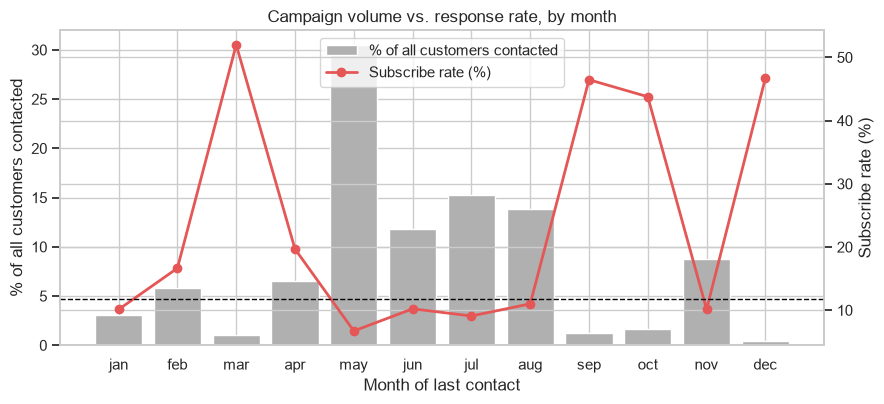

In [6]:
month_chrono = month.sort_values("month_order")
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.bar(month_chrono.month, month_chrono.pct_of_all_customers, color="#B0B0B0", label="% of all customers contacted")
ax1.set_ylabel("% of all customers contacted"); ax1.set_xlabel("Month of last contact")
ax2 = ax1.twinx()
ax2.plot(month_chrono.month, month_chrono.subscribe_rate_pct, color="#E45756", marker="o", lw=2, label="Subscribe rate (%)")
ax2.axhline(overall_rate*100, color="black", ls="--", lw=1)
ax2.set_ylabel("Subscribe rate (%)")
lines1, labels1 = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")
ax1.set_title("Campaign volume vs. response rate, by month")
plt.tight_layout()
plt.savefig("../reports/02_subscribe_by_month.png", dpi=150)
plt.show()

**What this shows.** This is the sharpest pattern in the whole dataset. **May alone is 30% of all
contacts, and converts at only 6.7%** — below the overall average and the single worst month.
**March, September, October and December convert at 44-52%**, four to seven times the average,
but together are only **4.4%** of contacts. The campaign's calling volume and its actual
effectiveness point in almost opposite directions by month. (This dataset has no year column, so
"month" is a repeating calendar month, not a specific date — a real seasonal or economic-cycle
effect cannot be told apart from a one-time event that happened to fall in those months.)

## 4. Subscription rate by contact type

`sql/11_subscription_rate_by_contact_type.sql`

In [7]:
contact = run_sql_file(con, "11_subscription_rate_by_contact_type.sql")
contact

,contact,n_customers,pct_of_all_customers,subscribe_rate_pct
0,cellular,29285,64.77,14.92
1,telephone,2906,6.43,13.42
2,unknown,13020,28.80,4.07


**What this shows.** **Cellular reaches 65% of customers and converts at 14.9%**, well above
average and matching Project 1's PSBC-style intuition that a personal mobile line is easier to
reach a real decision-maker on. **`contact = unknown` (29% of customers) converts at just 4.1%,
over 3 times worse than cellular** — this is the same finding from Phase 1, repeated here in the
direct comparison. Whatever "unknown" contact channel means operationally, it is a channel worth
avoiding or fixing, not a data gap to shrug off.

## 5. Subscription rate by previous campaign outcome

`sql/12_subscription_rate_by_previous_outcome.sql`

In [8]:
poutcome = run_sql_file(con, "12_subscription_rate_by_previous_outcome.sql")
poutcome

,poutcome,n_customers,pct_of_all_customers,subscribe_rate_pct
0,success,1511,3.34,64.73
1,other,1840,4.07,16.68
2,failure,4901,10.84,12.61
3,unknown,36959,81.75,9.16


**What this shows.** **A customer who said yes to a previous campaign says yes again 64.7% of the
time** — nearly 6 times the overall average, and by far the single strongest number in this
notebook. Even a customer whose previous campaign *failed* still converts at 12.6%, slightly above
the 11.7% baseline. First-time contacts (`unknown`, 82% of the file) convert at 9.2%, a little
*below* baseline. Having been sold to before, and having said yes even once, is worth more than
almost any demographic fact about the customer.

## Phase 2 summary (plain English)

Five patterns, in order of how strong they are:

1. **A past "yes" is the strongest predictor of a future "yes".** 64.7% of previously-successful
   customers convert again, versus 11.7% overall — nearly a 6x lift, and the single most valuable
   fact in this dataset.
2. **Timing matters more than almost anything about the customer.** March, September, October and
   December convert at 44-52%; May, which carries 30% of all calls, converts at just 6.7%. The
   campaign's calling volume was heaviest exactly when it worked least well.
3. **Cellular contact clearly outperforms `unknown` contact** (14.9% vs. 4.1%, over 3x), a channel
   effect independent of who the customer is.
4. **Life stage matters more than occupation status.** Students and retirees — the two groups
   with the least conventional "career" — respond far above average (28.7% and 22.8%), while
   blue-collar workers, the single largest job group, are among the lowest (7.3%).
5. **Education has a steady, gradual relationship with response** (8.6% → 10.6% → 15.0% from
   primary to tertiary), unlike the sharper, threshold-like jumps seen in timing and job.

**Where this points for Phase 3.** Timing (month) and prior outcome (poutcome) are both about the
*campaign*, not stable properties of the *customer* — they say more about when and how someone was
reached than who they are. Job, education, age and financial behavior (balance, existing loans)
are closer to durable customer traits. Segmentation in Phase 3 will lean on the customer-level
traits, and treat timing and prior-outcome effects as a lens to view the resulting segments
through in Phase 4, rather than mixing all of it into one undifferentiated set of cluster inputs.